In [ ]:
# pip install tensorflow

## Libraries

---


This code begins by importing the libraries necessary for the construccion, training and evaluation of learning model. The libraries include tools for file management, image processing, model building and visualization of the results.

In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import imghdr
import random
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from google.colab import drive
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint

drive.mount('/content/drive')

<ipython-input-1-be1c9e52a1e2>:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Mounted at /content/drive


## Memory Optimization and GPU

In [2]:
import tensorflow as tf

# Clear previous sessions and configure GPU memory
tf.keras.backend.clear_session()
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        # Limit GPU memory growth
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except RuntimeError as e:
        print(e)

## Define main routes
**base_dir:** specifies the location where the original images are located, showing the path in google drive

**output_dir:** this is the location where the organized datasets will be stored, located in google drive

**output_json:** defines the location and name of the file we will use to store the tag information categorising the dataset. Useful to have a structured record of the images.

In [3]:
# Define image path
#  Hugo's Data Path
# base_dir = "/content/drive/MyDrive/Colab Notebooks/Images DLGA"
# output_dir = "/content/drive/MyDrive/Colab Notebooks/dataset"
# output_json = "/content/drive/MyDrive/Colab Notebooks/labels.json"

# Anita's Data Path
base_dir = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/Images DLGA"
output_dir = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/dataset"
output_json = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/labels.json"

## Generating a JSON File for Image and Class Mapping
1.- A class dictionary is created and used to store the associations between the names of each image and the classes to which they belong.
  
2.-The loop is created to be able to go through all the folders inside the main directory taking into account that:


*   each subfolder is treated as a different class.
*   the folder name is considered as the label each image belongs to

Within each subfolder the images that will be stored in the dictionary as a **key-value** pair are traversed.

3.-Finally the dictionary is stored in a json file, which will later allow us to have a clear record of how the images are classified.

In [4]:
# Create a dictionary to store image-class mappings
image_class_dict = {}

# Iterate through each class (subfolder)
for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            image_class_dict[img] = cls

# Save to JSON file
with open(output_json, "w") as json_file:
    json.dump(image_class_dict, json_file, indent=4)

print(f"Class mapping saved to {output_json}")

Class mapping saved to /content/drive/MyDrive/Colab Notebooks - DLGA Project/labels.json


## Creation of output folders
We will create four folders inside the output directory, to organise the images according to their purpose in the training process of a learning model.

The folders that will be created are:


*   train: this will store images that will be used in the training of the model.
*   val: this will store the images that will be used to validate the performance of the model while it is being trained.
*   test: we will store the images reserved for the final evaluation of the model which does not interfere with the training.
*   mix: will be used as a general repository or for specific purposes as needed.

In [5]:
# Create output folders
for folder in ['train', 'val', 'test', 'mix']:
    os.makedirs(os.path.join(output_dir, folder), exist_ok=True)

## Split and copy the images into the folders, train, val and test.

Automatically organises each of the images from their original folders **(base_dir)** into previously created folders **(train, val, test and mix)** in the output directory **(output_dir)**.
The division of the images is done by means of **split_ratios**, defining the proportion in which the images will be divided, which in this case will be as follows:


*   train: 70% of the images
*   val: 20% of the images and
*   test: 10% of the images

For set separate folders are created for each existing class in the base_dir, adding **os.makedirs()** making sure that the folders exist and if not create them. The images are copied to the corresponding folders and the test images are copied to the mix folder.

In [ ]:
# Copy and split images into train, val, and test
def split_data(base_dir, output_dir, split_ratios=(0.7, 0.2, 0.1)):
    classes = os.listdir(base_dir)
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        images = os.listdir(cls_path)
        train, temp = train_test_split(images, test_size=1 - split_ratios[0], random_state=42)
        val, test = train_test_split(temp, test_size=split_ratios[2] / (split_ratios[1] + split_ratios[2]), random_state=42)

        for dataset, dataset_name in zip([train, val, test], ['train', 'val', 'test']):
            class_dir = os.path.join(output_dir, dataset_name, cls)
            os.makedirs(class_dir, exist_ok=True)
            for img in dataset:
                shutil.copy(os.path.join(cls_path, img), os.path.join(class_dir, img))

        # Copy test images to mix without subfolders
        for img in test:
            shutil.copy(os.path.join(cls_path, img), os.path.join(output_dir, 'mix', img))

split_data(base_dir, output_dir)

## Model configuration
Here we define some of the essential parameters that will be used in the image processing and training of the model.
With **img_size** we define the size to which the images will be resized before they are sent to the model, the images were scaled to 150 pixels wide and 150 pixels high.
A larger size had been tried, however the processing time and memory usage increased.

In [6]:
# Model parameters
img_size = (64, 64)  # Increased image size for better performance
batch_size = 32

## Creation of the generators
We create the generators that will load the images from the train, val and test folders.

Each generator creates images applying random enhancements to create more variety in the data and improve learning, evaluation during training and final evaluation without mixing the images ensuring accuracy and consistency.

In [7]:
# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)  # Added back test_datagen

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_dir, 'val'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(output_dir, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important for test set to maintain order
)

Found 13411 images belonging to 42 classes.
Found 3844 images belonging to 42 classes.
Found 1942 images belonging to 42 classes.


## Building and configuring the **Convolutional Neural Network (CNN)** model
In this code block we create a **CNN** model designed to classify images of multiple categories, the model has several layers that allow learning of increasingly complex visual characteristics.
The model is built using the sequential approach, which adds layers one by one, using **Conv2D** which detects visual characteristics of the images.

The layers increase in complexity as they have more filters than the previous one. **MaxPooling2D** has been used in each layer to reduce the size of each image while keeping only the most important features.

In [8]:
def create_memory_efficient_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(len(train_generator.class_indices), activation='softmax')
    ])

    return model

# Create the model
model = create_memory_efficient_cnn(input_shape=(*img_size, 3), num_classes=len(train_generator.class_indices))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model training
For this part of the code we prepare to train the model using advanced techniques to improve the efficiency and quality of learning, to save the trained model in a file for later use.

To improve the training we use different callbacks, such as:

*   **EarlyStopping:** stops training the model automatically if it stops improving no matter how many epochs have elapsed or are missing, in this case it waits for 5 consecutive epochs without improvement before stopping the training and resets to its best performing version.
*   **ReduceLROnPlateau:** decreases the learning rate when the model stagnates, aiding fine-grained learning by monitoring the loss of the validation set.

The model is configured to allow it to learn for a maximum of 100 epochs, **early_stopping** y **reduce_lr** strategies have been implemented to improve training.

The trained model is duly saved in an **.h5** file which will allow us to save it and use it later without the need to train it again.

In [9]:
# Compile with adaptive learning rate
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Advanced callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

model_checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Colab Notebooks - DLGA Project/best_model.h5",
    save_best_only=True,
    monitor='val_accuracy'
)

# Train with memory-efficient settings
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # Reduced from 100
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    # workers=4,  # Remove or set to 1 if using tf.distribute
    # use_multiprocessing=True  # Remove if using tf.distribute
)

# Save the final model
model.save("/content/drive/MyDrive/Colab Notebooks - DLGA Project/final_memory_efficient_model.h5")

# Optional: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
 32/420 ━━━━━━━━━━━━━━━━━━━━ 1:30:06 14s/step - accuracy: 0.1497 - loss: 4.0574

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 50/420 ━━━━━━━━━━━━━━━━━━━━ 1:25:21 14s/step - accuracy: 0.1820 - loss: 3.7901

KeyboardInterrupt: 

## Evaluation of the model
We will validate the performance of a previously trained model on a test data set, which is a crucial part of the model validation process.

This step allows us to obtain an estimate of the model's performance on data never seen during training, which helps to ensure that the model has learned general patterns and does not overfit.

In [13]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')

61/61 ━━━━━━━━━━━━━━━━━━━━ 758s 13s/step - accuracy: 0.8114 - loss: 0.6852
Test accuracy: 0.7868


## Loading of the trained model
Allows us to load the previously trained model from a stored file, this step is essential when we want to reuse a previously trained model without the need to re-train it from scratch, which saves resources and time.

This procedure is particularly important when deploying models in production.

In [14]:
# Load the trained model
# model = load_model("/content/drive/MyDrive/Colab Notebooks/model_cnn_improved_v2_2.h5")

# Anita's
model = load_model("/content/drive/MyDrive/Colab Notebooks - DLGA Project/final_memory_efficient_model.h5")

## Loading json with image classification names
This code is in charge of loading the previously created json file, which contains a mapping of real classes, this mapping allows to compare the predictions of the model with the real labels, calculate performance metrics and perform detailed analysis on the performance of the model, in addition to having the actual classification of each image in test and evaluate the performance of the model.

In [15]:
# Load the JSON with real class mappings
# json_path = "/content/drive/MyDrive/Colab Notebooks/labels.json"

#Anita's
json_path = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/labels.json"

with open(json_path, "r") as file:
    class_mapping = json.load(file)  # Dictionary {image_name: real_class}

## Visualisation of Predictions
In this step we will perform a comprehensive process of evaluation and visualisation of the predictions made, given the model previously trained on a set of randomly selected images.
It will allow direct visual comparison between the predictions made by the model and the actual classes of the images.

This approach will facilitate not only the identification of specific errors, but also the detection of possible problems of generalisation of the model.

In [16]:
# Define image size (same as used in training)
# mix_dir = "/content/drive/MyDrive/Colab Notebooks/dataset/mix"  # Folder where test images are stored

#Anita's
mix_dir = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/dataset/mix"# Folder where test images are stored

# Load class labels
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# Get 40 random images from mix
mix_images = os.listdir(mix_dir)
random.shuffle(mix_images)
mix_images = mix_images[:40]

# Plot predictions
fig, axes = plt.subplots(8, 5, figsize=(15, 20))
axes = axes.ravel()

for i, img_name in enumerate(mix_images):
    img_path = os.path.join(mix_dir, img_name)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    predicted_label = class_labels[predicted_class]

    # Get real class from JSON (if available)
    real_label = class_mapping.get(img_name, "Unknown")

    # Show image with predictions
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {predicted_label}\nReal: {real_label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Adding Description to the predicted Classified classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


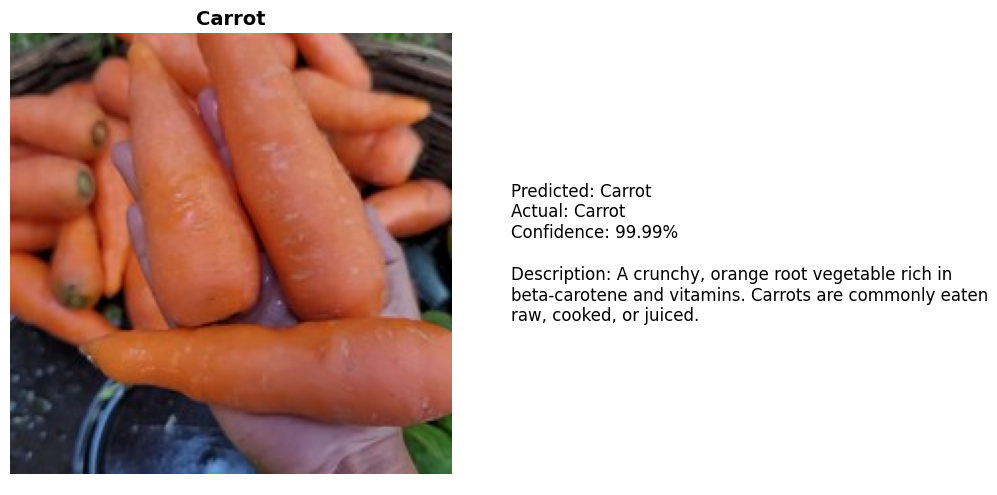

In [17]:
# csv_path = "/content/drive/MyDrive/Colab Notebooks/class_descriptions.csv"

# Anita'
csv_path = "/content/drive/MyDrive/Colab Notebooks - DLGA Project/class_descriptions.csv"

# Load class labels
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# Load descriptions from CSV
df = pd.read_csv(csv_path)
class_descriptions = dict(zip(df['Class'], df['Description']))  # Ensure correct column names

# Model input size
input_shape = model.input_shape
img_height, img_width = input_shape[1], input_shape[2]

# Select a random image
mix_images = os.listdir(mix_dir)
random_image = random.choice(mix_images)
img_path = os.path.join(mix_dir, random_image)

# Load and preprocess image
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Expand dims for prediction

# Set confidence threshold
CONFIDENCE_THRESHOLD = 0.5

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence_score = np.max(prediction) * 100  # Convert to percentage
predicted_label = class_labels[predicted_class]

# Get real class if available
real_label = class_mapping.get(random_image, "Unknown")

# Determine description or error message
if predicted_label == real_label:
    description = class_descriptions.get(predicted_label, "No description available")
else:
    description = "Model was unable to correctly classify this image."

# Create visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Show image
ax[0].imshow(image.load_img(img_path))
ax[0].axis("off")
ax[0].set_title(real_label, fontsize=14, fontweight="bold")

# Show details (including confidence score)
details = (
    f"Predicted: {predicted_label}\n"
    f"Actual: {real_label}\n"
    f"Confidence: {confidence_score:.2f}%\n\n"
    f"Description: {description}"
)
ax[1].text(0.1, 0.5, details, fontsize=12, va="center", wrap=True)
ax[1].axis("off")

plt.tight_layout()
plt.show()